# 04 — Test-set trading simulation

Simulate a **long-only** strategy on the chronological **test** split using envelope forecasts.

- Starting capital: **$10,000**
- At each decision day, the model predicts next-5-day `week_max` / `week_min` (cumulative log-price band).
- **Entry** when the forecast is bullish (configurable rule). If level-calibrated rules never fire, use **`top_quintile`** (trade the strongest relative forecasts).
- **P&L** = realized 5-day simple return on the target ticker (from actual log returns).
- **Non-overlapping** trades: after entering, wait 5 decision days before the next entry.

This is a research backtest, not live trading advice.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
for _ in range(3):
    if (PROJECT_ROOT / "src_regi").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Open notebook under Advanced Machine Learning Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src_regi.backtest import build_test_predictions, buy_and_hold_curve, simulate_strategy
from src_regi.config import load_config
from src_regi.data import load_log_returns

In [2]:
cfg = load_config(PROJECT_ROOT / "config_regi.json")
INITIAL_CAPITAL = 10_000.0
ENTRY_RULE = "top_quintile"  # relative bullish vs other test days; see rules below
TOP_FRACTION = 0.2  # used by top_quintile / wide_band rules
COST_BPS = 5.0  # round-trip cost per trade (5 bps each way -> 10 bps total approx)

decisions = build_test_predictions(cfg)
target = cfg["data"]["target_ticker"]
raw = load_log_returns(cfg)
print(f"Test decisions: {len(decisions)} | {decisions.index.min().date()} -> {decisions.index.max().date()}")
decisions.head()

Test decisions: 310 | 2022-09-27 -> 2023-12-19


,pred_max,pred_min,current_cum,true_max,true_min,fwd_log_return,fwd_simple_return,pred_mid,pred_upside,pred_downside,pred_range,pred_edge
date,,,,,,,,,,,,
2022-09-27,3.239599,0.473804,3.245203,3.304172,3.222882,0.058969,0.060743,1.856702,-0.005604,2.771399,2.765795,-1.388501
2022-09-28,3.230373,0.457490,3.270891,3.307357,3.222882,0.036466,0.037139,1.843932,-0.040518,2.813401,2.772883,-1.426960
2022-09-29,3.235514,0.456681,3.229533,3.307357,3.222882,0.071826,0.074468,1.846097,0.005981,2.772852,2.778833,-1.383435
2022-09-30,3.238202,0.447372,3.222882,3.307357,3.217679,-0.005203,-0.005190,1.842787,0.015320,2.775510,2.790830,-1.380095
2022-10-03,3.235777,0.459287,3.253147,3.307357,3.183480,-0.069667,-0.067296,1.847532,-0.017370,2.793860,2.776490,-1.405615


### Entry rules (`ENTRY_RULE`)

| Rule | Go long when |
|------|----------------|
| `upside_skew` | predicted upside to band max > predicted downside to band min |
| `mid_above_current` | predicted mid of band above today's cumulative log level |
| `combined` | both conditions above |
| `min_upside` | predicted upside > `MIN_UPSIDE` (log units) |
| `top_quintile` | `pred_edge` in top 20% on test (robust if levels are biased) |
| `top_upside_quintile` | `pred_upside` in top 20% |
| `wide_band` | predicted range in top 20% (volatility bet) |
| `pred_edge_positive` | predicted mid above current level |
| `oracle` | long when realized 5d return > 0 (cheating upper bound) |
| `always_long` | every eligible day (benchmark) |
| `always_flat` | never trade |

In [3]:
result = simulate_strategy(
    decisions,
    initial_capital=INITIAL_CAPITAL,
    entry_rule=ENTRY_RULE,
    min_upside=0.0,
    position_fraction=1.0,
    cost_bps=COST_BPS,
    non_overlap=True,
    hold_steps=cfg["data"]["forecast_horizon"],
    top_fraction=TOP_FRACTION,
)

bh = buy_and_hold_curve(decisions, raw[target], INITIAL_CAPITAL)

print("Strategy summary:")
for k, v in result.summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2f}")
    else:
        print(f"  {k}: {v}")

bh_return_pct = 100.0 * (bh.iloc[-1] / INITIAL_CAPITAL - 1.0)
print(f"  buy_hold_return_pct: {bh_return_pct:.2f}")

Strategy summary:
  initial_capital: 10000.00
  final_equity: 16214.65
  total_return_pct: 62.15
  num_trades: 14
  win_rate_pct: 71.43
  avg_trade_return_pct: 3.89
  total_pnl: 6214.65
  buy_hold_return_pct: 305.94


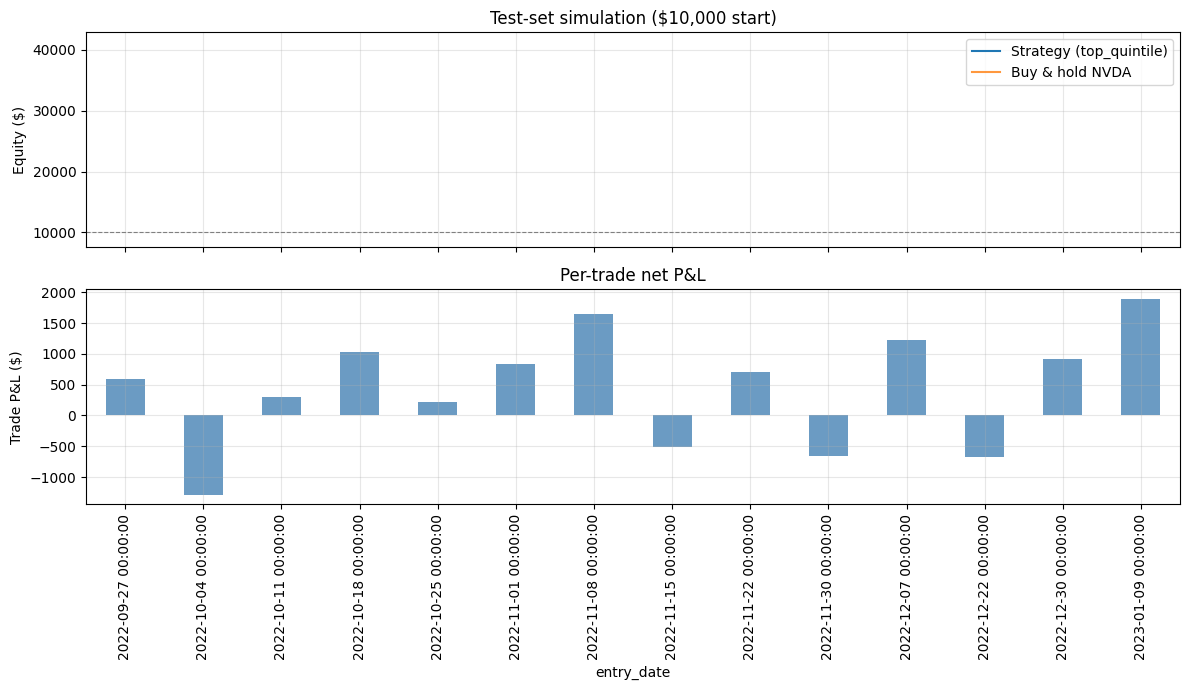

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

result.equity_curve.plot(ax=axes[0], label=f"Strategy ({ENTRY_RULE})", color="C0")
bh.reindex(result.equity_curve.index, method="ffill").plot(
    ax=axes[0], label=f"Buy & hold {target}", color="C1", alpha=0.8
)
axes[0].axhline(INITIAL_CAPITAL, color="gray", ls="--", lw=0.8)
axes[0].set_ylabel("Equity ($)")
axes[0].set_title(f"Test-set simulation (${INITIAL_CAPITAL:,.0f} start)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if len(result.trades):
    result.trades.set_index("entry_date")["pnl"].plot.bar(ax=axes[1], color="steelblue", alpha=0.8)
    axes[1].set_ylabel("Trade P&L ($)")
    axes[1].set_title("Per-trade net P&L")
else:
    axes[1].text(0.5, 0.5, "No trades", ha="center", va="center", transform=axes[1].transAxes)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
rules = ["top_quintile", "upside_skew", "pred_edge_positive", "wide_band", "always_long", "oracle"]
rows = []
for rule in rules:
    r = simulate_strategy(
        decisions,
        initial_capital=INITIAL_CAPITAL,
        entry_rule=rule,
        cost_bps=COST_BPS,
        non_overlap=True,
        hold_steps=cfg["data"]["forecast_horizon"],
        top_fraction=TOP_FRACTION,
    )
    rows.append({
        "rule": rule,
        "final_equity": r.summary["final_equity"],
        "return_pct": r.summary["total_return_pct"],
        "trades": r.summary["num_trades"],
        "win_rate_pct": r.summary["win_rate_pct"],
    })
rows.append({
    "rule": "buy_hold",
    "final_equity": bh.iloc[-1],
    "return_pct": bh_return_pct,
    "trades": 1,
    "win_rate_pct": float("nan"),
})
comparison = pd.DataFrame(rows).sort_values("return_pct", ascending=False)
comparison

,rule,final_equity,return_pct,trades,win_rate_pct
5,oracle,92161.826306,821.618263,46,100.000000
6,buy_hold,40594.290005,305.942900,1,NaN
4,always_long,36496.695738,264.966957,62,59.677419
3,wide_band,17536.034975,75.360350,19,73.684211
0,top_quintile,16214.651319,62.146513,14,71.428571
2,pred_edge_positive,10000.000000,0.000000,0,0.000000
1,upside_skew,10000.000000,0.000000,0,0.000000


In [6]:
if len(result.trades):
    display(result.trades.tail(10))
else:
    print("No trades triggered. Try ENTRY_RULE='always_long' or retrain Phase 2.")

,entry_date,invested,fwd_return,pnl,equity_after,pred_upside,pred_downside
4,2022-10-25,10641.020348,0.021266,215.647131,10856.667480,-0.112571,2.868045
5,2022-11-01,10856.667480,0.078195,838.083167,11694.750646,-0.097417,2.810350
6,2022-11-08,11694.750646,0.141350,1641.362266,13336.112912,-0.169411,2.851228
7,2022-11-15,13336.112912,-0.037681,-515.860022,12820.252891,-0.310258,2.991986
8,2022-11-22,12820.252891,0.055451,698.080520,13518.333411,-0.282890,2.927508
9,2022-11-30,13518.333411,-0.047450,-654.960949,12863.372462,-0.318517,2.969735
10,2022-12-07,12863.372462,0.096402,1227.188309,14090.560772,-0.265952,2.925397
11,2022-12-22,14090.560772,-0.047265,-680.084394,13410.476378,-0.276189,2.957021
12,2022-12-30,13410.476378,0.069386,917.082206,14327.558584,-0.205531,2.878322
13,2023-01-09,14327.558584,0.132711,1887.092736,16214.651319,-0.262685,2.961181
